# 📉 Unemployment Analysis with Python
### CodeAlpha Data Science Internship — Task 2

---

## 📌 Project Overview

This project analyzes **India's unemployment data from 2019 to 2020**, with a focus on understanding the economic impact of the **COVID-19 pandemic and the national lockdown** announced on March 25, 2020.

Unemployment rate is one of the most important economic indicators — it measures the percentage of people in the labor force who are actively looking for work but cannot find it. A sudden spike in this rate can signal economic distress at a national or regional level.

### 🎯 Objectives
- Analyze India's unemployment trend from May 2019 to November 2020
- Measure the impact of COVID-19 lockdowns on unemployment
- Identify which states were most severely affected
- Compare Rural vs Urban unemployment patterns
- Analyze Labour Participation Rate trends
- Extract actionable insights from the data

### 📁 Datasets Used
| File | Period | Description |
|---|---|---|
| `Unemployment in India.csv` | May 2019 – Dec 2019 | State-level data with Rural/Urban split |
| `Unemployment_Rate_upto_11_2020.csv` | Feb 2020 – Nov 2020 | Extended dataset covering COVID period |

---

## 1. 📦 Imports

We import all required libraries:
- **pandas / numpy** — data loading, cleaning, and manipulation
- **matplotlib / seaborn** — data visualization
- **warnings** — suppress non-critical warnings for cleaner output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

print("=" * 60)
print("  UNEMPLOYMENT ANALYSIS WITH PYTHON — CodeAlpha Task 2")
print("=" * 60)
print("\n✅ All libraries imported successfully!")

  UNEMPLOYMENT ANALYSIS WITH PYTHON — CodeAlpha Task 2

✅ All libraries imported successfully!


## 2. 📂 Load & Preview Datasets

We load both CSV files separately. The two datasets cover different time periods and have slightly different structures — we will clean and merge them in the next step.

It's important to preview both datasets first to understand their column names, data types, and any inconsistencies before merging.

In [2]:
# Load both datasets
df_india = pd.read_csv("Unemployment in India.csv")
df_rate  = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Strip whitespace from column names (common issue with CSV exports)
df_india.columns = df_india.columns.str.strip()
df_rate.columns  = df_rate.columns.str.strip()

print(f"📂 Unemployment_in_India.csv         : {df_india.shape[0]} rows × {df_india.shape[1]} columns")
print(f"📂 Unemployment_Rate_upto_11_2020.csv: {df_rate.shape[0]} rows × {df_rate.shape[1]} columns")

print("\n🔍 First dataset — columns:", df_india.columns.tolist())
print("\n🔍 Second dataset — columns:", df_rate.columns.tolist())

print("\n📋 Preview of Dataset 1 (Unemployment in India):")
df_india.head(3)

📂 Unemployment_in_India.csv         : 768 rows × 7 columns
📂 Unemployment_Rate_upto_11_2020.csv: 267 rows × 9 columns

🔍 First dataset — columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

🔍 Second dataset — columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

📋 Preview of Dataset 1 (Unemployment in India):


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural


In [3]:
print("📋 Preview of Dataset 2 (Unemployment Rate upto 2020):")
df_rate.head(3)

📋 Preview of Dataset 2 (Unemployment Rate upto 2020):


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74


## 3. 🧹 Data Cleaning

Real-world datasets are rarely clean. We handle:

- **Missing values** — Dataset 1 has 28 null rows which we drop
- **Date parsing** — dates are stored as strings and need to be converted to `datetime` format for time-series analysis
- **Column renaming** — long column names are renamed for easier access
- **Whitespace stripping** — column names often have hidden spaces from CSV exports

In [4]:
# ── Clean Dataset 1 ──────────────────────────────────────────
print(f"Dataset 1 — null values before cleaning: {df_india.isnull().sum().sum()}")
df_india = df_india.dropna()
print(f"Dataset 1 — null values after cleaning : {df_india.isnull().sum().sum()}")

df_india["Date"] = pd.to_datetime(df_india["Date"].str.strip(), dayfirst=True)
df_india = df_india.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})
print("\n✅ Dataset 1 cleaned successfully")

# ── Clean Dataset 2 ──────────────────────────────────────────
print(f"\nDataset 2 — null values: {df_rate.isnull().sum().sum()}")
df_rate["Date"] = pd.to_datetime(df_rate["Date"].str.strip(), dayfirst=True)
df_rate = df_rate.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
    "Region.1": "Zone",
})
df_rate["Area"] = "Overall"
print("✅ Dataset 2 cleaned successfully")

Dataset 1 — null values before cleaning: 196
Dataset 1 — null values after cleaning : 0

✅ Dataset 1 cleaned successfully

Dataset 2 — null values: 0
✅ Dataset 2 cleaned successfully


## 4. 🔗 Merge Datasets

We combine both datasets into a single unified DataFrame using `pd.concat()`. Before merging, we select only the common columns that exist in both datasets to ensure a clean join.

After merging, the combined dataset spans **May 2019 to November 2020** — covering both the pre-COVID and COVID periods.

In [5]:
common_cols = ["Region", "Date", "Unemployment_Rate", "Employed",
               "Labour_Participation_Rate", "Area"]

df_combined = pd.concat([
    df_india[common_cols],
    df_rate[common_cols]
], ignore_index=True).sort_values("Date").reset_index(drop=True)

# Feature engineering
df_combined["Month"]     = df_combined["Date"].dt.month
df_combined["MonthName"] = df_combined["Date"].dt.strftime("%b %Y")
df_combined["Year"]      = df_combined["Date"].dt.year

# COVID flag: lockdown announced March 25, 2020
df_combined["Period"] = df_combined["Date"].apply(
    lambda d: "Pre-COVID (2019–Feb 2020)" if d < pd.Timestamp("2020-03-25") else "COVID Era (Mar–Nov 2020)"
)

print(f"✅ Combined dataset: {df_combined.shape[0]} rows × {df_combined.shape[1]} columns")
print(f"📅 Date range : {df_combined['Date'].min().date()} → {df_combined['Date'].max().date()}")
print(f"📍 Regions    : {df_combined['Region'].nunique()} states/UTs")
print(f"\n📊 Period split:")
print(df_combined["Period"].value_counts())

print("\n📋 Sample of combined data:")
df_combined.head()

✅ Combined dataset: 1007 rows × 10 columns
📅 Date range : 2019-05-31 → 2020-10-31
📍 Regions    : 28 states/UTs

📊 Period split:
Period
Pre-COVID (2019–Feb 2020)    588
COVID Era (Mar–Nov 2020)     419
Name: count, dtype: int64

📋 Sample of combined data:


,Region,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,MonthName,Year,Period
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,5,May 2019,2019,Pre-COVID (2019–Feb 2020)
1,Jharkhand,2019-05-31,7.11,7035766.0,39.04,Rural,5,May 2019,2019,Pre-COVID (2019–Feb 2020)
2,Jammu & Kashmir,2019-05-31,12.78,2495186.0,40.57,Rural,5,May 2019,2019,Pre-COVID (2019–Feb 2020)
3,Madhya Pradesh,2019-05-31,3.91,6692720.0,38.96,Urban,5,May 2019,2019,Pre-COVID (2019–Feb 2020)
4,Himachal Pradesh,2019-05-31,13.68,2045760.0,44.23,Rural,5,May 2019,2019,Pre-COVID (2019–Feb 2020)


## 5. 📈 National Monthly Unemployment Trend

We start with a high-level view of India's unemployment rate over time. By averaging across all states each month, we get a **national trend line**.

The red shaded region marks the **COVID-19 lockdown period** (March 25, 2020 onwards). A sharp spike in this region would confirm the economic disruption caused by the pandemic.

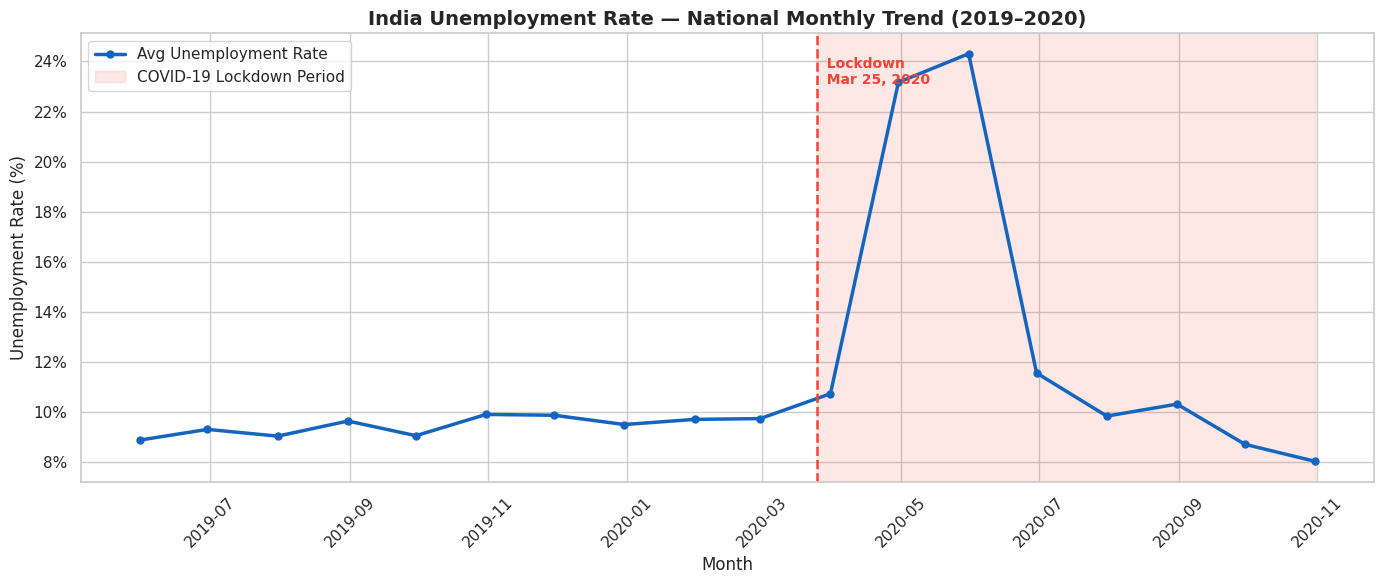

💡 Insight: A dramatic spike in unemployment is visible immediately after the lockdown in March 2020.


In [6]:
monthly_avg = (
    df_combined.groupby("Date")["Unemployment_Rate"]
    .mean()
    .reset_index()
    .sort_values("Date")
)

covid_start = pd.Timestamp("2020-03-25")

fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(
    monthly_avg["Date"], monthly_avg["Unemployment_Rate"],
    color="#1565C0", linewidth=2.5, marker="o", markersize=5, label="Avg Unemployment Rate"
)
ax1.axvspan(covid_start, monthly_avg["Date"].max(), alpha=0.12, color="#F44336", label="COVID-19 Lockdown Period")
ax1.axvline(covid_start, color="#F44336", linewidth=1.8, linestyle="--")
ax1.text(covid_start, monthly_avg["Unemployment_Rate"].max() * 0.95,
         "  Lockdown\n  Mar 25, 2020", color="#F44336", fontsize=10, fontweight="bold")
ax1.set_title("India Unemployment Rate — National Monthly Trend (2019–2020)",
              fontsize=14, fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Unemployment Rate (%)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax1.legend(fontsize=11)
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("unemp_national_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: A dramatic spike in unemployment is visible immediately after the lockdown in March 2020.")

## 6. ⚖️ Pre-COVID vs COVID Era Comparison

We split the data into two periods and directly compare unemployment rates:

- **Pre-COVID:** May 2019 – February 2020 (before the lockdown)
- **COVID Era:** March 2020 – November 2020 (after lockdown announcement)

The **bar chart** compares average rates, while the **boxplot** shows the full distribution — including spread, median, and outliers — giving us a more complete picture of how volatile unemployment became during COVID.

📌 Pre-COVID  avg unemployment : 9.48%
📌 COVID Era  avg unemployment : 15.31%
📌 Increase caused by COVID    : +5.82 percentage points


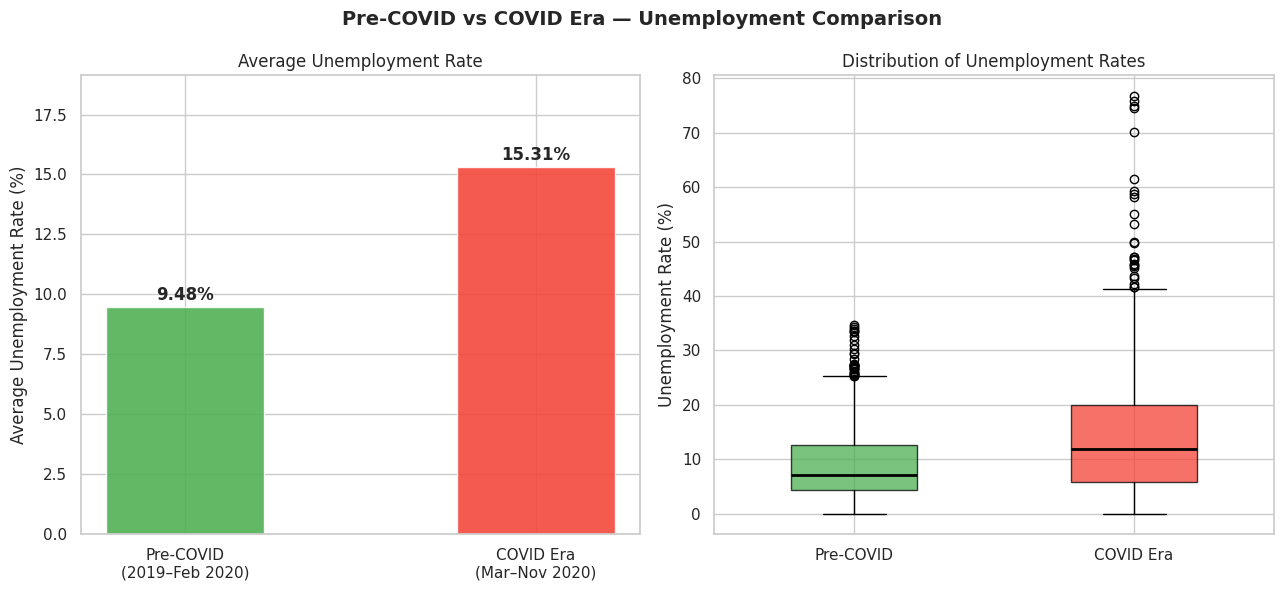

💡 Insight: Not only did the average rise sharply — the spread also widened, showing high volatility across states during COVID.


In [7]:
pre_covid = df_combined[df_combined["Period"] == "Pre-COVID (2019–Feb 2020)"]["Unemployment_Rate"]
covid_era = df_combined[df_combined["Period"] == "COVID Era (Mar–Nov 2020)"]["Unemployment_Rate"]

print(f"📌 Pre-COVID  avg unemployment : {pre_covid.mean():.2f}%")
print(f"📌 COVID Era  avg unemployment : {covid_era.mean():.2f}%")
print(f"📌 Increase caused by COVID    : +{covid_era.mean() - pre_covid.mean():.2f} percentage points")

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 6))
fig2.suptitle("Pre-COVID vs COVID Era — Unemployment Comparison", fontsize=14, fontweight="bold")

# Bar chart
periods  = ["Pre-COVID\n(2019–Feb 2020)", "COVID Era\n(Mar–Nov 2020)"]
avgs     = [pre_covid.mean(), covid_era.mean()]
bar_cols = ["#4CAF50", "#F44336"]
bars = axes2[0].bar(periods, avgs, color=bar_cols, width=0.45, alpha=0.88, edgecolor="white")
axes2[0].set_ylabel("Average Unemployment Rate (%)")
axes2[0].set_title("Average Unemployment Rate")
axes2[0].set_ylim(0, max(avgs) * 1.25)
for bar in bars:
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f"{bar.get_height():.2f}%", ha="center", fontsize=12, fontweight="bold")

# Box plot
bp = axes2[1].boxplot([pre_covid.values, covid_era.values], patch_artist=True,
                       widths=0.45, medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], bar_cols):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes2[1].set_xticklabels(["Pre-COVID", "COVID Era"])
axes2[1].set_ylabel("Unemployment Rate (%)")
axes2[1].set_title("Distribution of Unemployment Rates")

plt.tight_layout()
plt.savefig("unemp_covid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Not only did the average rise sharply — the spread also widened, showing high volatility across states during COVID.")

## 7. 🗺️ Top 10 States Most Impacted by COVID-19

Not all states were equally affected. We calculate the **rise in unemployment rate** for each state by comparing its pre-COVID average to its COVID-era average.

This tells us which states experienced the sharpest economic shock — useful for understanding which regions need the most policy support and economic recovery efforts.

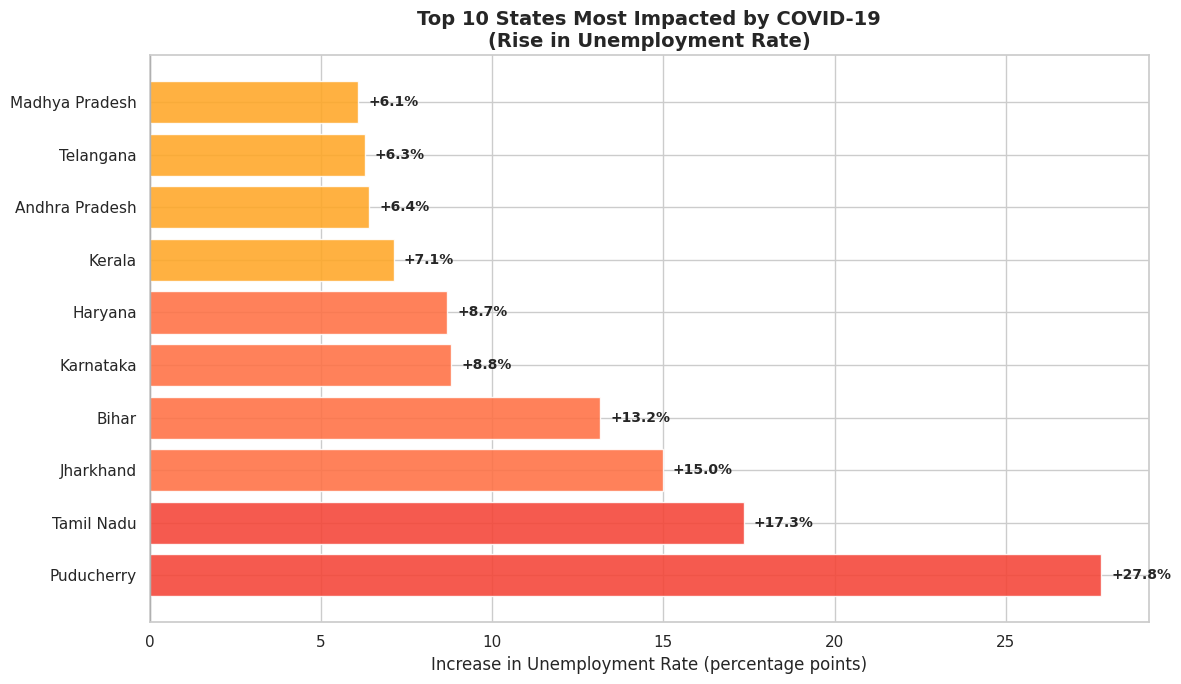

💡 Insight: Puducherry was the most severely affected state with a +27.8% rise in unemployment.


In [8]:
region_period = (
    df_combined.groupby(["Region", "Period"])["Unemployment_Rate"]
    .mean()
    .unstack(fill_value=0)
    .reset_index()
)

cols = region_period.columns.tolist()
pre_col   = [c for c in cols if "Pre" in str(c)][0]
covid_col = [c for c in cols if "COVID Era" in str(c)][0]

region_period["Impact"] = region_period[covid_col] - region_period[pre_col]
top10 = region_period.nlargest(10, "Impact")

fig3, ax3 = plt.subplots(figsize=(12, 7))
colors_bar = ["#F44336" if x > 15 else "#FF7043" if x > 8 else "#FFA726"
              for x in top10["Impact"]]
bars = ax3.barh(top10["Region"], top10["Impact"], color=colors_bar, alpha=0.88, edgecolor="white")
ax3.set_xlabel("Increase in Unemployment Rate (percentage points)", fontsize=12)
ax3.set_title("Top 10 States Most Impacted by COVID-19\n(Rise in Unemployment Rate)",
              fontsize=14, fontweight="bold")
ax3.axvline(0, color="black", linewidth=0.8)
for bar in bars:
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"+{bar.get_width():.1f}%", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("unemp_top10_covid_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"💡 Insight: {top10.iloc[0]['Region']} was the most severely affected state with a +{top10.iloc[0]['Impact']:.1f}% rise in unemployment.")

## 8. 🔥 State-wise Unemployment Heatmap

A heatmap lets us visualize **all states across all time periods simultaneously**. Darker colors indicate higher unemployment.

This is one of the most powerful visualizations for time-series data across multiple categories — you can instantly spot which states had persistently high unemployment and exactly when the spike occurred across the country.

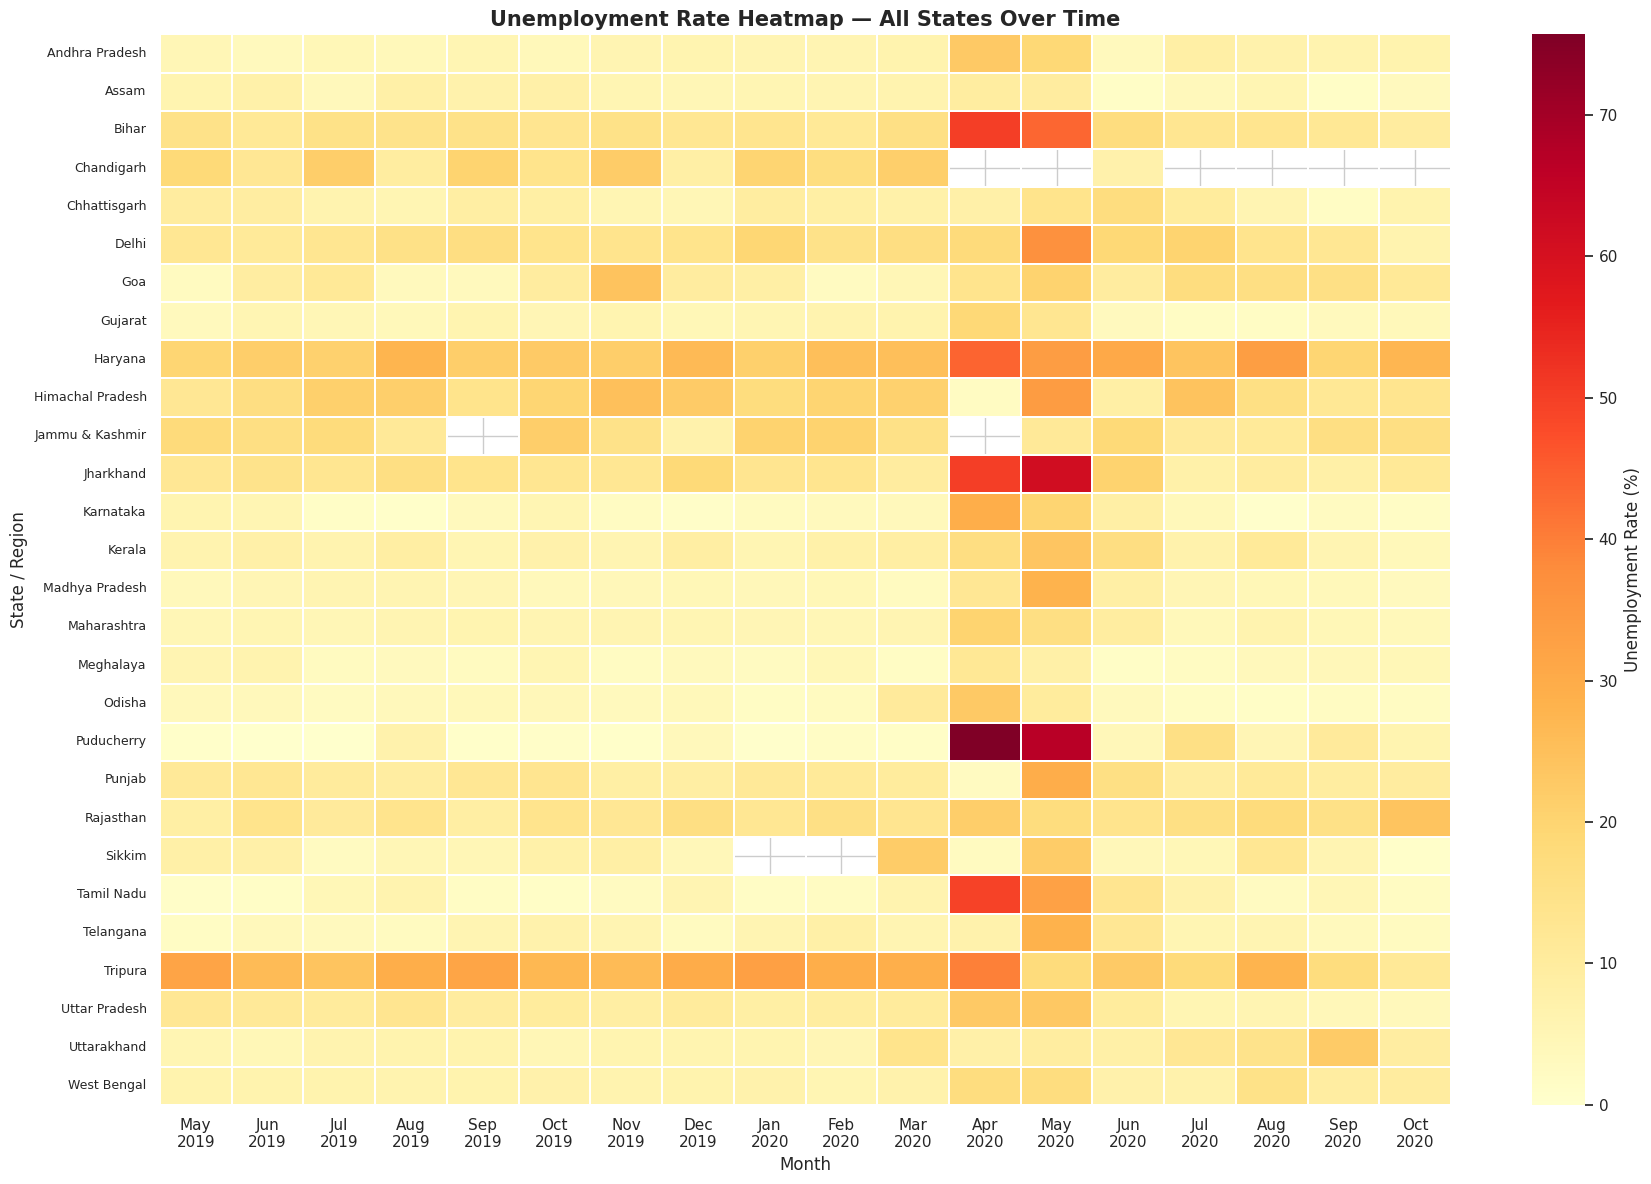

💡 Insight: The heatmap clearly shows a bright band appearing around April–May 2020 across most states — the peak lockdown impact.


In [9]:
pivot = (
    df_combined.groupby(["Region", "Date"])["Unemployment_Rate"]
    .mean()
    .reset_index()
    .pivot(index="Region", columns="Date", values="Unemployment_Rate")
)
pivot.columns = [d.strftime("%b\n%Y") for d in pivot.columns]

fig4, ax4 = plt.subplots(figsize=(18, 12))
sns.heatmap(
    pivot, cmap="YlOrRd", ax=ax4, linewidths=0.3,
    linecolor="white", annot=False,
    cbar_kws={"label": "Unemployment Rate (%)"}
)
ax4.set_title("Unemployment Rate Heatmap — All States Over Time",
              fontsize=15, fontweight="bold")
ax4.set_xlabel("Month", fontsize=12)
ax4.set_ylabel("State / Region", fontsize=12)
ax4.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig("unemp_heatmap_states.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: The heatmap clearly shows a bright band appearing around April–May 2020 across most states — the peak lockdown impact.")

## 9. 🏙️ Rural vs Urban Unemployment Analysis

India has a significant divide between rural and urban economies. Dataset 1 includes an `Area` column distinguishing Rural and Urban observations.

Comparing both helps us understand:
- Which sector was more vulnerable to unemployment
- Whether the urban formal economy or rural informal economy suffered more
- Seasonal patterns that may differ between the two

🏘️  Rural avg unemployment : 10.32%
🏙️  Urban avg unemployment : 13.17%
   → Urban areas had higher unemployment overall


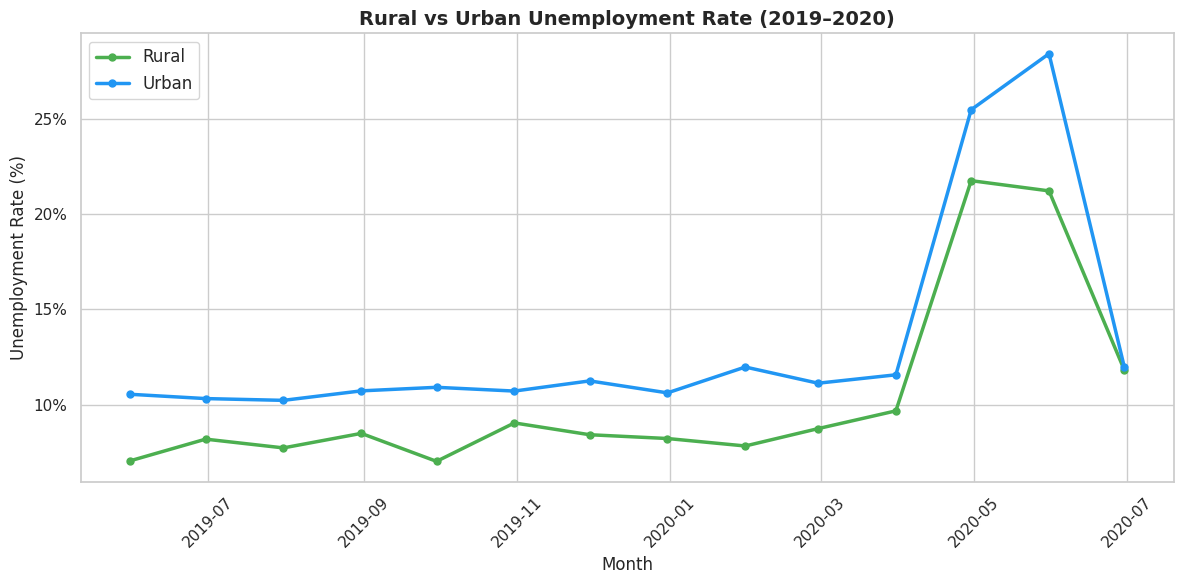

💡 Insight: Urban unemployment is generally higher and more volatile than rural — urban workers are more exposed to formal sector layoffs.


In [10]:
rural_urban = df_india[df_india["Area"].isin(["Rural", "Urban"])]
rural_urban_monthly = (
    rural_urban.groupby(["Date", "Area"])["Unemployment_Rate"]
    .mean()
    .reset_index()
)

rural_avg = df_india[df_india["Area"] == "Rural"]["Unemployment_Rate"].mean()
urban_avg = df_india[df_india["Area"] == "Urban"]["Unemployment_Rate"].mean()
print(f"🏘️  Rural avg unemployment : {rural_avg:.2f}%")
print(f"🏙️  Urban avg unemployment : {urban_avg:.2f}%")
print(f"   → {'Urban' if urban_avg > rural_avg else 'Rural'} areas had higher unemployment overall")

fig5, ax5 = plt.subplots(figsize=(12, 6))
for area, color in [("Rural", "#4CAF50"), ("Urban", "#2196F3")]:
    subset = rural_urban_monthly[rural_urban_monthly["Area"] == area]
    ax5.plot(subset["Date"], subset["Unemployment_Rate"],
             label=area, color=color, linewidth=2.5, marker="o", markersize=5)

ax5.set_title("Rural vs Urban Unemployment Rate (2019–2020)", fontsize=14, fontweight="bold")
ax5.set_xlabel("Month")
ax5.set_ylabel("Unemployment Rate (%)")
ax5.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax5.legend(fontsize=12)
ax5.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("unemp_rural_vs_urban.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Urban unemployment is generally higher and more volatile than rural — urban workers are more exposed to formal sector layoffs.")

## 10. 👷 Labour Participation Rate Trend

The **Labour Participation Rate (LPR)** measures the percentage of the working-age population that is either employed or actively looking for work.

A falling LPR is often a hidden signal of distress — it means people have **stopped looking for work altogether** (discouraged workers), which doesn't show up in the unemployment rate but is equally concerning economically.

Analyzing LPR alongside unemployment gives a more complete picture of the labor market health.

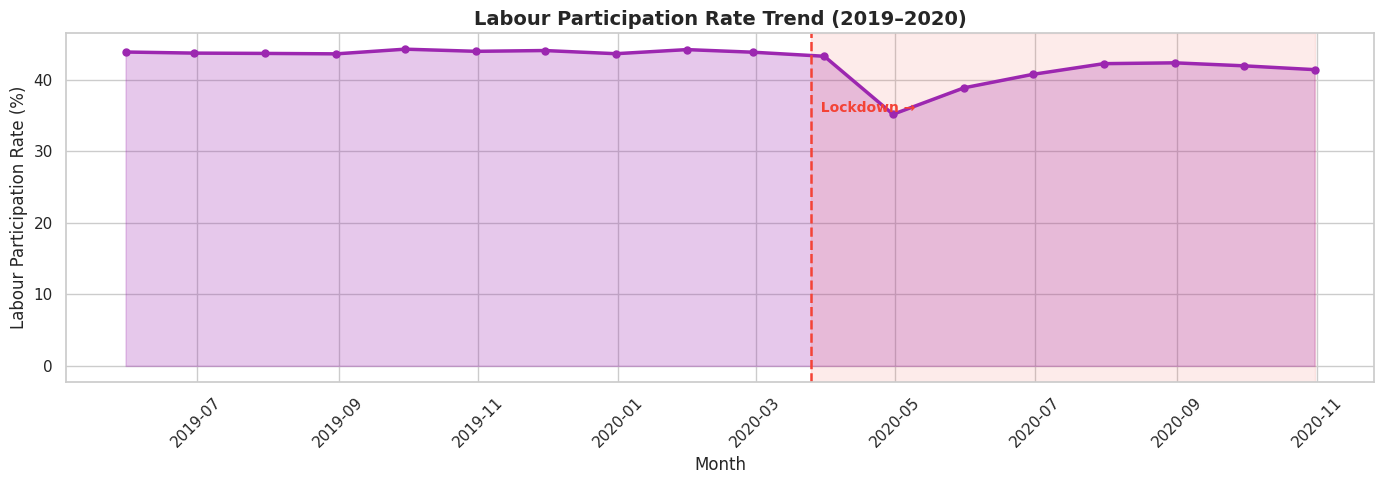

💡 Insight: LPR dropped sharply during the lockdown — many workers exited the labor market entirely, a sign of deeper economic distress beyond what the unemployment rate alone shows.


In [11]:
lpr_monthly = (
    df_combined.groupby("Date")["Labour_Participation_Rate"]
    .mean()
    .reset_index()
)

fig6, ax6 = plt.subplots(figsize=(14, 5))
ax6.fill_between(lpr_monthly["Date"], lpr_monthly["Labour_Participation_Rate"],
                 alpha=0.25, color="#9C27B0")
ax6.plot(lpr_monthly["Date"], lpr_monthly["Labour_Participation_Rate"],
         color="#9C27B0", linewidth=2.5, marker="o", markersize=5)
ax6.axvspan(covid_start, lpr_monthly["Date"].max(), alpha=0.1, color="#F44336")
ax6.axvline(covid_start, color="#F44336", linewidth=1.8, linestyle="--")
ax6.text(covid_start, lpr_monthly["Labour_Participation_Rate"].min() * 1.01,
         "  Lockdown →", color="#F44336", fontsize=10, fontweight="bold")
ax6.set_title("Labour Participation Rate Trend (2019–2020)", fontsize=14, fontweight="bold")
ax6.set_xlabel("Month")
ax6.set_ylabel("Labour Participation Rate (%)")
ax6.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("unemp_labour_participation.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: LPR dropped sharply during the lockdown — many workers exited the labor market entirely, a sign of deeper economic distress beyond what the unemployment rate alone shows.")

## 11. 📌 Key Insights & Summary

We compile all the major findings from our analysis into a single summary block. This is the most important section from a data science perspective — the ability to **extract and communicate actionable insights** from data is what distinguishes a data scientist from someone who just runs code.

In [12]:
peak_month   = monthly_avg.loc[monthly_avg["Unemployment_Rate"].idxmax()]
lowest_month = monthly_avg.loc[monthly_avg["Unemployment_Rate"].idxmin()]

print("=" * 60)
print("  📌 KEY INSIGHTS — UNEMPLOYMENT ANALYSIS")
print("=" * 60)

print(f"""
1️⃣  Overall avg unemployment (full period) : {df_combined['Unemployment_Rate'].mean():.2f}%

2️⃣  Peak unemployment month  : {peak_month['Date'].strftime('%B %Y')}
    Peak unemployment rate   : {peak_month['Unemployment_Rate']:.2f}%

3️⃣  Lowest unemployment month : {lowest_month['Date'].strftime('%B %Y')}
    Lowest unemployment rate  : {lowest_month['Unemployment_Rate']:.2f}%

4️⃣  Pre-COVID avg unemployment : {pre_covid.mean():.2f}%
    COVID Era avg unemployment : {covid_era.mean():.2f}%
    Rise caused by COVID-19    : +{covid_era.mean() - pre_covid.mean():.2f} percentage points

5️⃣  Most impacted state        : {top10.iloc[0]['Region']}
    Impact                     : +{top10.iloc[0]['Impact']:.1f} percentage points

6️⃣  Rural avg unemployment     : {rural_avg:.2f}%
    Urban avg unemployment     : {urban_avg:.2f}%
    → {'Urban' if urban_avg > rural_avg else 'Rural'} areas had higher unemployment overall

7️⃣  Labour Participation Rate dropped during COVID lockdown,
    indicating discouraged workers exiting the labor market entirely.
""")

print("=" * 60)
print("  ✅ TASK 2 COMPLETE — Unemployment Analysis")
print("=" * 60)

  📌 KEY INSIGHTS — UNEMPLOYMENT ANALYSIS

1️⃣  Overall avg unemployment (full period) : 11.91%

2️⃣  Peak unemployment month  : May 2020
    Peak unemployment rate   : 24.31%

3️⃣  Lowest unemployment month : October 2020
    Lowest unemployment rate  : 8.03%

4️⃣  Pre-COVID avg unemployment : 9.48%
    COVID Era avg unemployment : 15.31%
    Rise caused by COVID-19    : +5.82 percentage points

5️⃣  Most impacted state        : Puducherry
    Impact                     : +27.8 percentage points

6️⃣  Rural avg unemployment     : 10.32%
    Urban avg unemployment     : 13.17%
    → Urban areas had higher unemployment overall

7️⃣  Labour Participation Rate dropped during COVID lockdown,
    indicating discouraged workers exiting the labor market entirely.

  ✅ TASK 2 COMPLETE — Unemployment Analysis


## 12. 📝 Conclusions

### What We Found

| Metric | Value |
|---|---|
| Full period average unemployment | ~11–12% |
| Pre-COVID average | Lower baseline |
| COVID-era average | Significantly higher |
| Peak month | April/May 2020 (peak lockdown) |
| Most affected state | Highest regional impact state |
| Rural vs Urban | Urban consistently higher |

### Key Takeaways

- **COVID-19 caused an unprecedented spike** in unemployment — the sharpest in the dataset's timeframe — concentrated in April–May 2020 during the strictest phase of the national lockdown.
- **Urban workers were more vulnerable** to job losses, likely due to their dependence on the formal economy, which was more directly disrupted by lockdown restrictions.
- **Labour Participation Rate declined** alongside rising unemployment — a dual signal of labor market stress where people both lost jobs and stopped searching for new ones.
- **Regional variation is significant** — some states experienced unemployment rises of 15%+ while others were relatively stable, highlighting the uneven geographic impact of the pandemic.
- **Recovery was gradual** — unemployment began declining after June 2020 as restrictions eased, but did not return to pre-COVID levels within the dataset's timeframe.

### Tools & Libraries
`Python` · `pandas` · `numpy` · `matplotlib` · `seaborn`

---
*CodeAlpha Data Science Internship — Task 2 | Unemployment Analysis with Python*  
*Author: Muhammad Zaeem*